In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sqlalchemy.orm import Session
import scikit_posthocs as sp

from april.database import get_engine
from april.fs import PLOT_DIR
from april.utils import microsoft_colors, prettify_dataframe, cd_plot, get_cd
from april.enums import Base, Strategy, Heuristic

sns.set_style('white')
pd.set_option('display.max_rows', 50)
%config InlineBackend.figure_format = 'retina'

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU found
Memory growth set
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU found
Memory growth set
Creating Evaluation table


In [2]:
out_dir = PLOT_DIR / 'isj-2019'
eval_file = out_dir / 'eval.pkl'

### Helper objects

In [24]:
synth_datasets = ['paper', 'p2p', 'small', 'medium', 'large', 'huge', 'gigantic', 'wide']
bpic_datasets = ['bpic12', 'bpic13', 'bpic15', 'bpic17']
anonymous_datasets = ['real']
datasets = synth_datasets + bpic_datasets + anonymous_datasets
dataset_types = ['Synthetic', 'Real-life']

binet_ads = ["BINetv1", "BINetv2", "BINetv3"]
nn_ads = ["DAE", "DAELTN"] + binet_ads
h_ads = nn_ads + [ "Likelihood+", "t-STIDE+", "Naive+"]
d_ads = ["naive", "sampling", "Likelihood", "OC-SVM"]
ads = h_ads + d_ads
# ads = ['dae', 'naive', 'random', 'sampling']
# ads = ["P2PDAE", "P2PDAELTN"]
h_ads = ads = ["DAE", "DAELTN", "DAELTNFROZEN"]

heuristics = [r'$best$', r'$default$', r'$elbow_\downarrow$', r'$elbow_\uparrow$', 
              r'$lp_\leftarrow$', r'$lp_\leftrightarrow$', r'$lp_\rightarrow$']
print(ads)

['DAE', 'DAELTN', 'DAELTNFROZEN']


## Retrieve evaluations from pickle file

In [25]:
evaluation = pd.read_pickle(eval_file)

In [26]:
print(evaluation.columns)

Index(['file_name', 'date', 'hyperparameters', 'training_duration',
       'training_host', 'ad', 'dataset_name', 'process_model', 'noise',
       'dataset_id', 'axis', 'base', 'heuristic', 'strategy', 'label',
       'attribute_name', 'perspective', 'precision', 'recall', 'f1'],
      dtype='object')


In [27]:
evaluation.head(1)

,file_name,date,hyperparameters,training_duration,training_host,ad,dataset_name,process_model,noise,dataset_id,axis,base,heuristic,strategy,label,attribute_name,perspective,precision,recall,f1
0,paper-0.3-1_dae_20250424-134746.449773.keras,2025-04-24 13:47:51.167952,"{'epochs': 8, 'batch_size': 100}",4.718179,Dev-RTX,DAE,paper-0.3-1,paper,0.3,1,0,scores,best,single,Normal,name,Control Flow,1.0,0.857715,0.923409


In [28]:
print(evaluation["ad"].unique())

['DAE' 'DAELTNFROZEN']


### Add identifier for BPIC datasets and filter for ADs

In [29]:
evaluation = evaluation.query(f'ad in {ads} and label == "Anomaly"')
display(evaluation.head(10))

,file_name,date,hyperparameters,training_duration,training_host,ad,dataset_name,process_model,noise,dataset_id,axis,base,heuristic,strategy,label,attribute_name,perspective,precision,recall,f1
1,paper-0.3-1_dae_20250424-134746.449773.keras,2025-04-24 13:47:51.167952,"{'epochs': 8, 'batch_size': 100}",4.718179,Dev-RTX,DAE,paper-0.3-1,paper,0.3,1,0,scores,best,single,Anomaly,name,Control Flow,0.705394,1.000000,0.827251
3,paper-0.3-1_dae_20250424-134746.449773.keras,2025-04-24 13:47:51.167952,"{'epochs': 8, 'batch_size': 100}",4.718179,Dev-RTX,DAE,paper-0.3-1,paper,0.3,1,0,scores,best,single,Anomaly,user,Data,0.000000,0.000000,0.000000
5,paper-0.3-1_dae_20250424-134746.449773.keras,2025-04-24 13:47:51.167952,"{'epochs': 8, 'batch_size': 100}",4.718179,Dev-RTX,DAE,paper-0.3-1,paper,0.3,1,1,scores,best,single,Anomaly,name,Control Flow,0.319345,0.891429,0.470234
7,paper-0.3-1_dae_20250424-134746.449773.keras,2025-04-24 13:47:51.167952,"{'epochs': 8, 'batch_size': 100}",4.718179,Dev-RTX,DAE,paper-0.3-1,paper,0.3,1,1,scores,best,single,Anomaly,user,Data,0.000000,0.000000,0.000000
9,paper-0.3-1_dae_20250424-134746.449773.keras,2025-04-24 13:47:51.167952,"{'epochs': 8, 'batch_size': 100}",4.718179,Dev-RTX,DAE,paper-0.3-1,paper,0.3,1,2,scores,best,single,Anomaly,name,Control Flow,0.319345,0.891429,0.470234
11,paper-0.3-1_dae_20250424-134746.449773.keras,2025-04-24 13:47:51.167952,"{'epochs': 8, 'batch_size': 100}",4.718179,Dev-RTX,DAE,paper-0.3-1,paper,0.3,1,2,scores,best,single,Anomaly,user,Data,0.000000,0.000000,0.000000
13,paper-0.3-1_dae_20250424-134746.449773.keras,2025-04-24 13:47:51.167952,"{'epochs': 8, 'batch_size': 100}",4.718179,Dev-RTX,DAE,paper-0.3-1,paper,0.3,1,0,scores,best,attribute,Anomaly,name,Control Flow,0.705394,1.000000,0.827251
15,paper-0.3-1_dae_20250424-134746.449773.keras,2025-04-24 13:47:51.167952,"{'epochs': 8, 'batch_size': 100}",4.718179,Dev-RTX,DAE,paper-0.3-1,paper,0.3,1,0,scores,best,attribute,Anomaly,user,Data,0.272727,0.342857,0.303797
17,paper-0.3-1_dae_20250424-134746.449773.keras,2025-04-24 13:47:51.167952,"{'epochs': 8, 'batch_size': 100}",4.718179,Dev-RTX,DAE,paper-0.3-1,paper,0.3,1,1,scores,best,attribute,Anomaly,name,Control Flow,0.319345,0.891429,0.470234
19,paper-0.3-1_dae_20250424-134746.449773.keras,2025-04-24 13:47:51.167952,"{'epochs': 8, 'batch_size': 100}",4.718179,Dev-RTX,DAE,paper-0.3-1,paper,0.3,1,1,scores,best,attribute,Anomaly,user,Data,0.297872,0.205882,0.243478


In [30]:
evaluation['perspective-label'] = evaluation['perspective'] + '-' + evaluation['label']
evaluation['attribute_name-label'] = evaluation['attribute_name'] + '-' + evaluation['label']
evaluation['dataset_type'] = 'Synthetic'
evaluation.loc[evaluation['process_model'].str.contains('bpic'), 'dataset_type'] = 'Real-life'
evaluation.loc[evaluation['process_model'].str.contains('real'), 'dataset_type'] = 'Real-life'

### Filter for best strategy

In `5.1 Best Strategy.ipynb` we find that $\tau_0$ and $\tau_a$ seem to work best overall. Intuatively it makes sense to set a threshold $\tau$ per attribute, hence we select $\tau_a$ whereever applicable.

In [31]:
_filtered_evaluation = evaluation.query(f'ad in {h_ads} and (strategy == "{Strategy.ATTRIBUTE}"'
                                       f' or (strategy == "{Strategy.SINGLE}" and process_model == "bpic12")'
                                       f' or (strategy == "{Strategy.SINGLE}" and ad == "Naive+")) or ad in {d_ads}')

### Filter for best heuristic

In `5.2 Best Heuristic.ipynb` we find that $lp_\rightarrow$ works best overall, aparat from DAE. For DAE we use $elbow_\uparrow$. For all default methods we use $default$.

In [32]:
# filtered_evaluation = _filtered_evaluation.query(f'heuristic == "{Heuristic.DEFAULT}"'
#                                                  f' or (heuristic == "{Heuristic.LP_MEAN}" and ad != "dae")'
#                                                  f' or (heuristic == "{Heuristic.ELBOW_UP}" and ad == "dae")'
#                                                  f' or (heuristic == "{Heuristic.LP_MEAN}" and ad != "daeltn")'
#                                                  f' or (heuristic == "{Heuristic.ELBOW_UP}" and ad == "daeltn")'
#                                                  f' or (heuristic == "{Heuristic.LP_MEAN}" and ad != "daeltnfrozen")'
#                                                  f' or (heuristic == "{Heuristic.ELBOW_UP}" and ad == "daeltnfrozen")'
#                                                  )

In [33]:
# filtered_evaluation = _filtered_evaluation.query(f'heuristic == "{Heuristic.DEFAULT}"'
#                                                  f' or (heuristic == "{Heuristic.LP_MEAN}" and ad != "DAE")'
#                                                  f' or (heuristic == "{Heuristic.ELBOW_UP}" and ad == "DAE")'
#                                                  f' or (heuristic == "{Heuristic.LP_MEAN}" and ad != "DAELTN")'
#                                                  f' or (heuristic == "{Heuristic.ELBOW_UP}" and ad == "DAELTN")'
#                                                  f' or (heuristic == "{Heuristic.LP_MEAN}" and ad != "DAELTNFROZEN")'
#                                                  f' or (heuristic == "{Heuristic.ELBOW_UP}" and ad == "DAELTNFROZEN")'
#                                                 )

In [34]:
filtered_evaluation = _filtered_evaluation.query(f'heuristic == "{Heuristic.DEFAULT}"'
                                                 f' or (heuristic == "{Heuristic.LP_MEAN}" and ad != "DAE")'
                                                 f' or (heuristic == "{Heuristic.LP_LEFT}" and ad == "DAE")'
                                                 f' or (heuristic == "{Heuristic.LP_MEAN}" and ad != "DAELTN")'
                                                 f' or (heuristic == "{Heuristic.LP_LEFT}" and ad == "DAELTN")'
                                                 f' or (heuristic == "{Heuristic.LP_MEAN}" and ad != "DAELTNFROZEN")'
                                                 f' or (heuristic == "{Heuristic.LP_LEFT}" and ad == "DAELTNFROZEN")'
                                                )

In [35]:
# filtered_evaluation = _filtered_evaluation.query(f'heuristic == "{Heuristic.DEFAULT}"'
#                                                  f' or (heuristic == "{Heuristic.LP_MEAN}" and ad != "DAE")'
#                                                  f' or (heuristic == "{Heuristic.BEST}" and ad == "DAE")'
#                                                  f' or (heuristic == "{Heuristic.LP_MEAN}" and ad != "DAELTN")'
#                                                  f' or (heuristic == "{Heuristic.BEST}" and ad == "DAELTN")'
#                                                  f' or (heuristic == "{Heuristic.LP_MEAN}" and ad != "DAELTNFROZEN")'
#                                                  f' or (heuristic == "{Heuristic.BEST}" and ad == "DAELTNFROZEN")'
#                                                 )

## Plot featured in paper (Figure 10)

In [36]:
df = filtered_evaluation.query('axis == 2')  # We give results on attribute level
df = prettify_dataframe(df)
print(df.groupby(['ad', 'file_name', 'dataset_type', 'dataset_name', 'perspective'])[['precision', 'recall', 'f1']])

C:\Users\devas\AppData\Local\Temp\ipykernel_27356\378049143.py:13: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  df = df.stack(1).stack(1).reset_index()
C:\Users\devas\AppData\Local\Temp\ipykernel_27356\378049143.py:13: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  df = df.stack(1).stack(1).reset_index()
c:\Users\devas\anaconda3\envs\ltn\lib\site-packages\seaborn\axisgrid.py:854: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  func(*plot_args, **plot_kwargs)


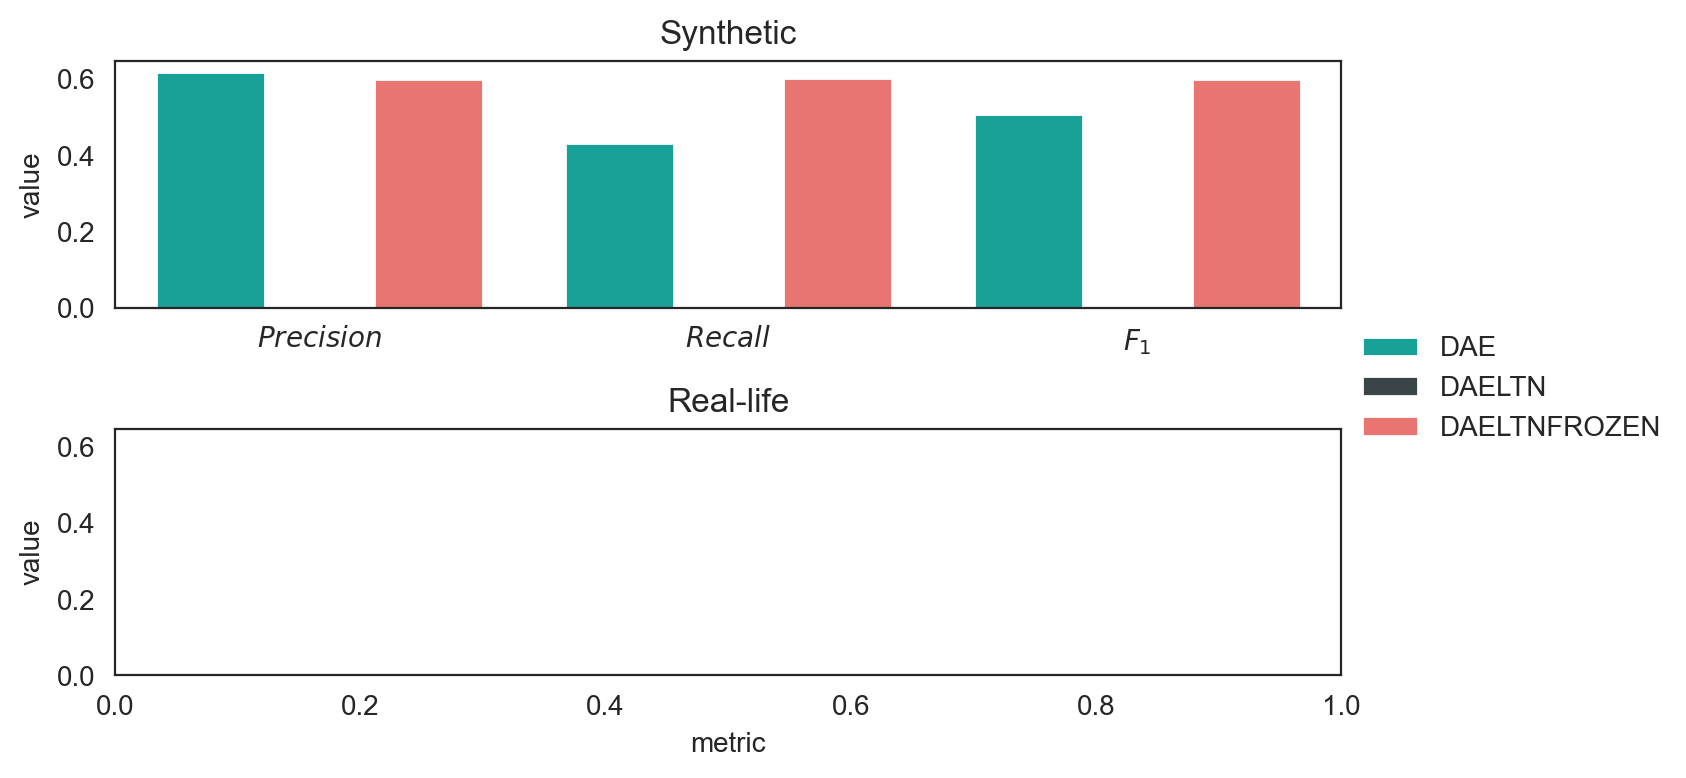

In [52]:
# Set up dataframe
df = filtered_evaluation.query('axis == 0')  # We give results on case level
df = prettify_dataframe(df)
# print(df)
# We first have to average for the two perspectives (to always weigh CF and Data 1 to 1), then we can average over all runs and datasets
df = df.groupby(['ad', 'file_name', 'dataset_type', 'dataset_name', 'perspective'])[['precision', 'recall', 'f1']].mean().reset_index()
df = df.groupby(['ad', 'file_name', 'dataset_type', 'dataset_name'])[['precision', 'recall', 'f1']].mean().reset_index()
df['f1'] = 2 * df['recall'] * df['precision'] / (df['recall'] + df['precision'])  # We recalculate the F1 score based on the new averaged P and R values

# We want to penalize DAE for running out of memory on some of the BPIC datasets, hence we set the F1 score to zero where DAE has NaN values
df = pd.pivot_table(df, index=['ad'], columns=['dataset_type', 'dataset_name'], values=['precision', 'recall', 'f1'])
df = df.fillna(0)
df = df.stack(1).stack(1).reset_index()

# Plot
df = df.melt(id_vars=['ad', 'dataset_type', 'dataset_name'], value_vars=['precision', 'recall', 'f1'], var_name='metric')
df = df.replace('f1', r'$F_1$').replace('precision', r'$Precision$').replace('recall', r'$Recall$')

g = sns.FacetGrid(data=df, row='dataset_type', sharex=False, sharey=True, despine=False, height=2, aspect=3.5, row_order=dataset_types)
g = g.map_dataframe(sns.barplot, x='metric', y='value', hue='ad', palette=microsoft_colors, hue_order=ads, order=[r'$Precision$', r'$Recall$', r'$F_1$'])
g = g.add_legend()

g.axes.flat[0].set(title='Synthetic')
g.axes.flat[1].set(title='Real-life')

g.savefig(str(out_dir / 'eval_overall.pdf'))

## Significance Test (Fig. 11)

Pairwise significance shown in CD diagram (Demsar 2006).

In [ ]:
df = filtered_evaluation.query('axis == 2 and dataset_type == "Synthetic"')
df = prettify_dataframe(df)

# We first have to average for the two perspectives (to always weigh CF and Data 1 to 1), then we can average over all runs and datasets
df = df.groupby(['ad', 'file_name', 'dataset_type', 'dataset_name', 'perspective'])[['precision', 'recall', 'f1']].mean().reset_index()
df = df.groupby(['ad', 'dataset_type', 'dataset_name'])[['precision', 'recall', 'f1']].mean().reset_index()
df['f1'] = 2 * df['recall'] * df['precision'] / (df['recall'] + df['precision'])  # We recalculate the F1 score based on the new averaged P and R values
# df['f1'] = df['f1'].fillna(0)

# We want to penalize DAE for running out of memory on some of the BPIC datasets, hence we set the F1 score to zero where DAE has NaN values
df = pd.pivot_table(df, index=['ad', 'dataset_type'], columns=['dataset_name'], values=['f1'])
df = df.fillna(0)
df = df.stack(1).reset_index()

# Rank by F1 score
df['rank'] = df.groupby(['dataset_name'])['f1'].rank(ascending=False)

k = len(df['ad'].unique())
n = len(df) / k
alpha = 0.05
cd = get_cd(k, n, alpha)  # Critical difference for k groups, n blocks

ranks = df.groupby(['ad'])['rank'].agg(np.mean).dropna().round(2)
fig = cd_plot(ranks, cd=cd, reverse=True)
fig.savefig(str(out_dir / 'significance.pdf'))

NameError: name 'filtered_evaluation' is not defined

Pairwise significance using Nemenyi-Friedman.

In [39]:
# nemenyi_df = df.groupby(['ad', 'dataset_name'])[['rank']].mean().dropna().reset_index()
# pc = sp.posthoc_nemenyi_friedman(nemenyi_df, y_col='rank', group_col='ad', block_col='dataset_name', melted=True)
# heatmap_args = {'linewidths': 0.25, 'linecolor': '0.5', 'clip_on': False, 'square': True, 'cbar_ax_bbox': [0.80, 0.35, 0.04, 0.3]}
# fig = sp.sign_plot(pc, **heatmap_args)

In [40]:
# dunn_df = df.groupby(['ad', 'dataset_name'])['rank'].mean().dropna().reset_index()
# pc = sp.posthoc_dunn(dunn_df, val_col='rank', group_col='ad', p_adjust='bonferroni')
# heatmap_args = {'linewidths': 0.25, 'linecolor': '0.5', 'clip_on': False, 'square': True, 'cbar_ax_bbox': [0.80, 0.35, 0.04, 0.3]}
# fig = sp.sign_plot(pc, **heatmap_args)

## Result table featured in the paper (Table 2)

In [41]:
df = filtered_evaluation.query('axis in [0, 2]')
df = prettify_dataframe(df)
df = df.groupby(['axis', 'process_model', 'dataset_name', 'ad', 'file_name', 'perspective'])[['precision', 'recall', 'f1']].mean().reset_index()
df = df.groupby(['axis', 'process_model', 'dataset_name', 'ad', 'file_name'])[['precision', 'recall', 'f1']].mean().reset_index()
df['f1'] = 2 * df['recall'] * df['precision'] / (df['recall'] + df['precision'])

df = pd.pivot_table(df, index=['axis', 'ad'], columns=['process_model', 'dataset_name'], values=['precision', 'recall', 'f1'])
df = df.fillna(0)
df = df.stack(1).stack(1).reset_index()
df.to_excel(str(out_dir / 'table.xlsx'), index=False)

df = pd.pivot_table(df, index=['axis', 'ad'], columns=['process_model'], values=['precision', 'recall', 'f1'], aggfunc=np.mean)
df.round(3)

C:\Users\devas\AppData\Local\Temp\ipykernel_27356\4188120552.py:9: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  df = df.stack(1).stack(1).reset_index()


C:\Users\devas\AppData\Local\Temp\ipykernel_27356\4188120552.py:9: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  df = df.stack(1).stack(1).reset_index()
C:\Users\devas\AppData\Local\Temp\ipykernel_27356\4188120552.py:12: FutureWarning: The provided callable <function mean at 0x0000017EC9AE2B80> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  df = pd.pivot_table(df, index=['axis', 'ad'], columns=['process_model'], values=['precision', 'recall', 'f1'], aggfunc=np.mean)


f1 precision recall
process_model           Paper     Paper  Paper
axis      ad                                  
Attribute DAE           0.291     0.513  0.203
          DAELTNFROZEN  0.276     0.326  0.240
Case      DAE           0.508     0.618  0.432
          DAELTNFROZEN  0.601     0.600  0.603

In [42]:
from datetime import datetime
print(datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print("Finished")

2025-05-02 18:58:09
Finished
